<a href="https://colab.research.google.com/github/mariea-aashif/Statistical-Learning-e22374/blob/main/assignment_7_kalman_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q. Analytical Derivation

We are given the linear Gaussian filter model

$$
x_k^- = A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1},
$$

$$
y_k^- = H_kx_k^- + z_k,
$$

where

$$
x_{k-1}^+ \sim \mathscr{N}(m_{k-1},P_{k-1}),
$$

and the process noise and measurement noise are assumed to be independent Gaussian random variables,

$$
w_{k-1}\sim \mathscr{N}(0,\Sigma_p),
$$

$$
z_k\sim \mathscr{N}(0,\Sigma_m).
$$

---

## 1. Distribution of the predicted state

Since \(x_k^-\) is a linear transformation of Gaussian random variables, it is also Gaussian.

Taking the expectation,

$$
\mathbb{E}[x_k^-]
=
\mathbb{E}[A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1}].
$$

Using linearity of expectation,

$$
\mathbb{E}[x_k^-]
=
A_{k-1}\mathbb{E}[x_{k-1}^+] + G_{k-1}\mathbb{E}[w_{k-1}].
$$

Since

$$
\mathbb{E}[x_{k-1}^+] = m_{k-1}
$$

and

$$
\mathbb{E}[w_{k-1}] = 0,
$$

we get

$$
m_k^- = A_{k-1}m_{k-1}.
$$

Now the covariance is

$$
P_k^- = \mathrm{Var}(x_k^-).
$$

Therefore,

$$
P_k^-
=
\mathrm{Var}(A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1}).
$$

Since \(x_{k-1}^+\) and \(w_{k-1}\) are independent,

$$
P_k^-
=
A_{k-1}P_{k-1}A_{k-1}^T
+
G_{k-1}\Sigma_pG_{k-1}^T.
$$

Hence,

$$
x_k^- \sim \mathscr{N}(m_k^-,P_k^-),
$$

where

$$
m_k^- = A_{k-1}m_{k-1},
$$

and

$$
P_k^- =
A_{k-1}P_{k-1}A_{k-1}^T
+
G_{k-1}\Sigma_pG_{k-1}^T.
$$

---

## 2. Distribution of the predicted measurement

The predicted measurement is

$$
y_k^- = H_kx_k^- + z_k.
$$

Since \(x_k^-\) and \(z_k\) are Gaussian, and \(y_k^-\) is a linear combination of them, \(y_k^-\) is also Gaussian.

Taking expectation,

$$
\mathbb{E}[y_k^-]
=
\mathbb{E}[H_kx_k^- + z_k].
$$

Therefore,

$$
\mathbb{E}[y_k^-]
=
H_k\mathbb{E}[x_k^-] + \mathbb{E}[z_k].
$$

Since

$$
\mathbb{E}[x_k^-] = m_k^-
$$

and

$$
\mathbb{E}[z_k] = 0,
$$

we get

$$
\mathbb{E}[y_k^-] = H_km_k^-.
$$

Now the covariance is

$$
\mathrm{Var}(y_k^-)
=
\mathrm{Var}(H_kx_k^- + z_k).
$$

Since \(x_k^-\) and \(z_k\) are independent,

$$
\mathrm{Var}(y_k^-)
=
H_kP_k^-H_k^T + \Sigma_m.
$$

Therefore,

$$
y_k^- \sim
\mathscr{N}
\left(
H_km_k^-,
H_kP_k^-H_k^T+\Sigma_m
\right).
$$

---

## 3. Joint distribution of \(x_k^-\) and \(y_k^-\)

Since \(x_k^-\) and \(y_k^-\) are jointly Gaussian, we can write

$$
\begin{bmatrix}
x_k^-\\
y_k^-
\end{bmatrix}
\sim
\mathscr{N}
\left(
\begin{bmatrix}
\mathbb{E}[x_k^-]\\
\mathbb{E}[y_k^-]
\end{bmatrix},
\begin{bmatrix}
\mathrm{Var}(x_k^-) & \mathrm{Cov}(x_k^-,y_k^-)\\
\mathrm{Cov}(y_k^-,x_k^-) & \mathrm{Var}(y_k^-)
\end{bmatrix}
\right).
$$

We already have

$$
\mathbb{E}[x_k^-] = m_k^-,
$$

and

$$
\mathbb{E}[y_k^-] = H_km_k^-.
$$

Also,

$$
\mathrm{Var}(x_k^-) = P_k^-,
$$

and

$$
\mathrm{Var}(y_k^-) = H_kP_k^-H_k^T+\Sigma_m.
$$

Now,

$$
\mathrm{Cov}(x_k^-,y_k^-)
=
\mathrm{Cov}(x_k^-,H_kx_k^-+z_k).
$$

Since \(z_k\) is independent of \(x_k^-\),

$$
\mathrm{Cov}(x_k^-,z_k)=0.
$$

Therefore,

$$
\mathrm{Cov}(x_k^-,y_k^-)
=
\mathrm{Cov}(x_k^-,H_kx_k^-).
$$

Using the covariance rule,

$$
\mathrm{Cov}(x_k^-,H_kx_k^-)
=
P_k^-H_k^T.
$$

Similarly,

$$
\mathrm{Cov}(y_k^-,x_k^-)
=
H_kP_k^-.
$$

Therefore,

$$
\begin{bmatrix}
x_k^-\\
y_k^-
\end{bmatrix}
\sim
\mathscr{N}
\left(
\begin{bmatrix}
m_k^-\\
H_km_k^-
\end{bmatrix},
\begin{bmatrix}
P_k^- & P_k^-H_k^T\\
H_kP_k^- & H_kP_k^-H_k^T+\Sigma_m
\end{bmatrix}
\right).
$$

---

## 4. Conditional distribution and Kalman filter update

For a jointly Gaussian vector,

$$
\begin{bmatrix}
x\\
y
\end{bmatrix}
\sim
\mathscr{N}
\left(
\begin{bmatrix}
\mu_x\\
\mu_y
\end{bmatrix},
\begin{bmatrix}
\Sigma_{xx} & \Sigma_{xy}\\
\Sigma_{yx} & \Sigma_{yy}
\end{bmatrix}
\right),
$$

the conditional distribution of \(x\) given \(y=y_{\mathrm{obs}}\) is

$$
x|y=y_{\mathrm{obs}}
\sim
\mathscr{N}
\left(
\mu_x+\Sigma_{xy}\Sigma_{yy}^{-1}(y_{\mathrm{obs}}-\mu_y),
\Sigma_{xx}-\Sigma_{xy}\Sigma_{yy}^{-1}\Sigma_{yx}
\right).
$$

For this problem,

$$
\mu_x = m_k^-,
$$

$$
\mu_y = H_km_k^-,
$$

$$
\Sigma_{xx} = P_k^-,
$$

$$
\Sigma_{xy} = P_k^-H_k^T,
$$

and

$$
\Sigma_{yy} = H_kP_k^-H_k^T+\Sigma_m.
$$

Therefore,

$$
x_k^+ =
(x_k^-|y_k^-=y_k^{\mathrm{obs}})
\sim
\mathscr{N}(m_k,P_k).
$$

The updated mean is

$$
m_k
=
m_k^-
+
P_k^-H_k^T
(H_kP_k^-H_k^T+\Sigma_m)^{-1}
(y_k^{\mathrm{obs}}-H_km_k^-).
$$

Define the Kalman gain as

$$
K_k
=
P_k^-H_k^T
(H_kP_k^-H_k^T+\Sigma_m)^{-1}.
$$

Then the updated mean becomes

$$
m_k = m_k^- + K_k(y_k^{\mathrm{obs}}-H_km_k^-).
$$

The updated covariance is

$$
P_k
=
P_k^-
-
P_k^-H_k^T
(H_kP_k^-H_k^T+\Sigma_m)^{-1}
H_kP_k^-.
$$

Using the definition of \(K_k\),

$$
P_k
=
P_k^- - K_kH_kP_k^-.
$$

Therefore,

$$
P_k = (I-K_kH_k)P_k^-.
$$

Hence,

$$
x_k^+
\sim
\mathscr{N}(m_k,P_k),
$$

where

$$
K_k =
P_k^-H_k^T(H_kP_k^-H_k^T+\Sigma_m)^{-1},
$$

$$
m_k =
m_k^- + K_k(y_k^{\mathrm{obs}}-H_km_k^-),
$$

and

$$
P_k =
(I-K_kH_k)P_k^-.
$$

---

## 5. Conditional expectation and conditional variance

From the conditional Gaussian result,

$$
x_k^-|y_k^-=y_k^{\mathrm{obs}}
\sim
\mathscr{N}(m_k,P_k).
$$

Therefore,

$$
\mathbb{E}[x_k^-|y_k^-=y_k^{\mathrm{obs}}]
=
m_k.
$$

That is,

$$
\mathbb{E}[x_k^-|y_k^-=y_k^{\mathrm{obs}}]
=
m_k^- + K_k(y_k^{\mathrm{obs}}-H_km_k^-).
$$

Also,

$$
\mathrm{Var}(x_k^-|y_k^-=y_k^{\mathrm{obs}})
=
P_k.
$$

That is,

$$
\mathrm{Var}(x_k^-|y_k^-=y_k^{\mathrm{obs}})
=
(I-K_kH_k)P_k^-.
$$

# Q. 1-D Example

Consider the scalar linear Gaussian filter model

$$
x_k^- = ax_{k-1}^+ + w_{k-1},
\qquad
w_{k-1}\sim \mathscr{N}(0,q),
$$

$$
y_k^- = hx_k^- + z_k,
\qquad
z_k\sim \mathscr{N}(0,r).
$$

The prior distribution is

$$
x_0 \sim \mathscr{N}(m_0,P_0).
$$

The set of all observed measurements up to time step \(k\) is

$$
Y_k = \{y_1^{\mathrm{obs}},y_2^{\mathrm{obs}},\dots,y_k^{\mathrm{obs}}\}.
$$

## 1. Prediction step

From the system model,

$$
x_k^- = ax_{k-1}^+ + w_{k-1}.
$$

Taking expectation,

$$
\mathbb{E}[x_k^-]
=
\mathbb{E}[ax_{k-1}^+ + w_{k-1}].
$$

Using linearity of expectation,

$$
m_k^- = a\mathbb{E}[x_{k-1}^+] + \mathbb{E}[w_{k-1}].
$$

Since

$$
\mathbb{E}[x_{k-1}^+] = m_{k-1}
$$

and

$$
\mathbb{E}[w_{k-1}] = 0,
$$

we get

$$
m_k^- = am_{k-1}.
$$

Now, the predicted covariance is

$$
P_k^- = \mathrm{Var}(x_k^-).
$$

Therefore,

$$
P_k^- = \mathrm{Var}(ax_{k-1}^+ + w_{k-1}).
$$

Since \(x_{k-1}^+\) and \(w_{k-1}\) are independent,

$$
P_k^- = a^2P_{k-1} + q.
$$

Hence, the prediction equations are

$$
m_k^- = am_{k-1},
$$

and

$$
P_k^- = a^2P_{k-1} + q.
$$

## 2. Update step

The measurement model is

$$
y_k^- = hx_k^- + z_k.
$$

The predicted measurement mean is

$$
\mathbb{E}[y_k^-] = hm_k^-.
$$

The predicted measurement covariance is

$$
S_k = h^2P_k^- + r.
$$

The innovation, or measurement residual, is the difference between the observed measurement and the predicted measurement:

$$
v_k = y_k^{\mathrm{obs}} - hm_k^-.
$$

The Kalman gain for the scalar case is

$$
K_k = \frac{P_k^-h}{S_k}.
$$

Therefore, the updated mean is

$$
m_k = m_k^- + K_kv_k.
$$

Substituting \(K_k\) and \(v_k\),

$$
m_k
=
m_k^- +
\frac{P_k^-h}{S_k}
\left(y_k^{\mathrm{obs}} - hm_k^-\right).
$$

The updated covariance is

$$
P_k = (1-K_kh)P_k^-.
$$

Substituting the Kalman gain,

$$
P_k
=
\left(1-\frac{P_k^-h^2}{S_k}\right)P_k^-.
$$

## 3. Predictive measurement distribution

Before seeing the measurement \(y_k^{\mathrm{obs}}\), the predicted state is

$$
x_k^-|Y_{k-1} \sim \mathscr{N}(m_k^-,P_k^-).
$$

Since

$$
y_k^- = hx_k^- + z_k,
$$

where

$$
z_k\sim \mathscr{N}(0,r),
$$

the predictive measurement distribution is also Gaussian.

The mean is

$$
\mathbb{E}[y_k^-|Y_{k-1}] = hm_k^-.
$$

The variance is

$$
\mathrm{Var}(y_k^-|Y_{k-1}) = h^2P_k^- + r.
$$

Therefore,

$$
p(y_k^-|Y_{k-1})
=
\mathscr{N}
\left(
hm_k^-,
h^2P_k^- + r
\right).
$$

## 4. Posterior-predictive measurement distribution

After observing \(y_k^{\mathrm{obs}}\), the updated state distribution is

$$
x_k^+|Y_k \sim \mathscr{N}(m_k,P_k).
$$

The measurement model is still

$$
y_k^- = hx_k^+ + z_k.
$$

Therefore, the posterior-predictive measurement distribution is Gaussian.

The mean is

$$
\mathbb{E}[y_k^-|Y_k] = hm_k.
$$

The variance is

$$
\mathrm{Var}(y_k^-|Y_k) = h^2P_k + r.
$$

Therefore,

$$
p(y_k^-|Y_k)
=
\mathscr{N}
\left(
hm_k,
h^2P_k + r
\right).
$$

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [21]:
# Suitable numerical values for the scalar Kalman filter

a = 1.0       # state transition coefficient
h = 1.0       # measurement coefficient
q = 0.2       # process noise variance
r = 1.0       # measurement noise variance

m0 = 0.0      # initial mean
P0 = 4.0      # initial variance

N = 30        # number of time steps

np.random.seed(10)

In [22]:
# Generate true states and noisy measurements

true_x = np.zeros(N)
measurements = np.zeros(N)

true_x[0] = 0.0

for k in range(1, N):
    process_noise = np.random.normal(0, np.sqrt(q))
    true_x[k] = a * true_x[k-1] + process_noise

for k in range(N):
    measurement_noise = np.random.normal(0, np.sqrt(r))
    measurements[k] = h * true_x[k] + measurement_noise

In [23]:
# Kalman filter implementation for the scalar case

m = m0
P = P0

prior_means = []
prior_vars = []
posterior_means = []
posterior_vars = []

for k in range(N):

    # Prediction step
    m_minus = a * m
    P_minus = a**2 * P + q

    # Measurement prediction
    S = h**2 * P_minus + r

    # Innovation
    v = measurements[k] - h * m_minus

    # Kalman gain
    K = (P_minus * h) / S

    # Update step
    m = m_minus + K * v
    P = (1 - K * h) * P_minus

    # Store values
    prior_means.append(m_minus)
    prior_vars.append(P_minus)
    posterior_means.append(m)
    posterior_vars.append(P)

prior_means = np.array(prior_means)
prior_vars = np.array(prior_vars)
posterior_means = np.array(posterior_means)
posterior_vars = np.array(posterior_vars)

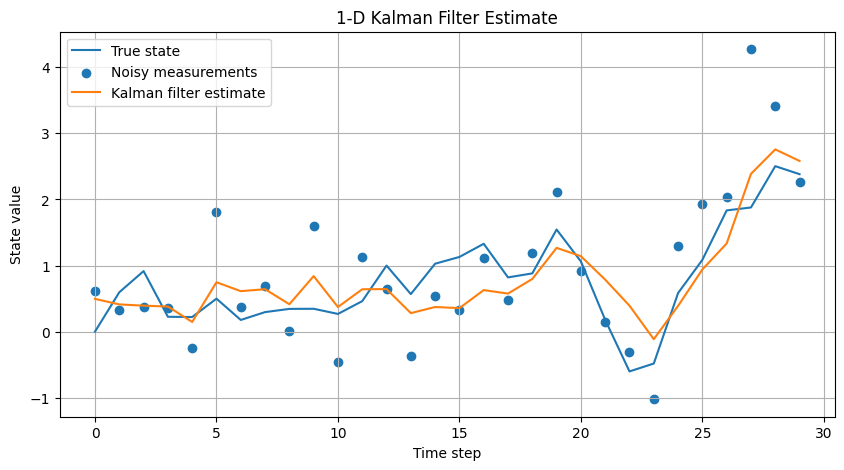

In [24]:
# Plot true state, noisy measurements, and filtered estimate

plt.figure(figsize=(10, 5))

plt.plot(true_x, label="True state")
plt.scatter(range(N), measurements, label="Noisy measurements")
plt.plot(posterior_means, label="Kalman filter estimate")

plt.xlabel("Time step")
plt.ylabel("State value")
plt.title("1-D Kalman Filter Estimate")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
# Gaussian probability density function

def gaussian_pdf(x, mean, variance):
    return (1 / np.sqrt(2 * np.pi * variance)) * np.exp(
        -0.5 * ((x - mean) ** 2) / variance
    )

In [26]:
# Animate the prior and posterior distributions

x_axis = np.linspace(-8, 8, 500)

fig, ax = plt.subplots(figsize=(9, 5))

prior_line, = ax.plot([], [], label="Prior distribution")
posterior_line, = ax.plot([], [], label="Posterior distribution")

measurement_line = ax.axvline(0, linestyle="--", label="Measurement")

ax.set_xlim(-8, 8)
ax.set_ylim(0, 1.0)
ax.set_xlabel("State value")
ax.set_ylabel("Probability density")
ax.set_title("Prior and Posterior Distributions in 1-D Kalman Filter")
ax.legend()
ax.grid(True)

def init():
    prior_line.set_data([], [])
    posterior_line.set_data([], [])
    measurement_line.set_xdata([0, 0])
    return prior_line, posterior_line, measurement_line

def update(frame):
    prior_pdf = gaussian_pdf(x_axis, prior_means[frame], prior_vars[frame])
    posterior_pdf = gaussian_pdf(x_axis, posterior_means[frame], posterior_vars[frame])

    prior_line.set_data(x_axis, prior_pdf)
    posterior_line.set_data(x_axis, posterior_pdf)
    measurement_line.set_xdata([measurements[frame], measurements[frame]])

    ax.set_title(f"1-D Kalman Filter: Time Step {frame + 1}")

    return prior_line, posterior_line, measurement_line

animation = FuncAnimation(
    fig,
    update,
    frames=N,
    init_func=init,
    interval=600,
    blit=True
)

plt.close(fig)

HTML(animation.to_jshtml())

# Q. 2D-Position Estimation

## Part A

Consider a two-dimensional constant-velocity dynamical system.

The hidden state at time step \(k\) is

$$
x_k =
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where \(p_x(k)\) and \(p_y(k)\) are the position components, while \(v_x(k)\) and \(v_y(k)\) are the velocity components.

The measurement contains only the position components:

$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The linear Gaussian state-space filter model is

$$
x_k^- = Ax_{k-1}^+ + Gw_{k-1},
$$

$$
y_k^- = Hx_k^+ + z_k.
$$

## 1. State transition matrix \(A\)

For constant-velocity motion in the \(x\)-direction,

$$
p_x(k) = p_x(k-1) + v_x(k-1)\Delta t.
$$

Similarly, for the \(y\)-direction,

$$
p_y(k) = p_y(k-1) + v_y(k-1)\Delta t.
$$

Since the velocity is assumed to be constant between two consecutive time steps,

$$
v_x(k) = v_x(k-1),
$$

and

$$
v_y(k) = v_y(k-1).
$$

Therefore, the state update equations can be written as

$$
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
p_x(k-1)\\
p_y(k-1)\\
v_x(k-1)\\
v_y(k-1)
\end{bmatrix}.
$$

Hence,

$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix}.
$$

## 2. Measurement matrix \(H\)

The measurement vector contains only the position components:

$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The state vector is

$$
x_k =
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix}.
$$

Since the measurement gives only \(p_x(k)\) and \(p_y(k)\), the measurement equation is

$$
y_k = Hx_k + z_k.
$$

Therefore,

$$
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix}
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix}
+
z_k.
$$

Hence,

$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix}.
$$

## 3. Process noise matrix \(G\)

In a constant-velocity model, process noise is commonly introduced as random acceleration.

Let the acceleration noise be

$$
w_{k-1} =
\begin{bmatrix}
a_x(k-1)\\
a_y(k-1)
\end{bmatrix}.
$$

Using the basic kinematic equation,

$$
p = p_0 + v_0\Delta t + \frac{1}{2}a\Delta t^2,
$$

the effect of acceleration noise on the position components is

$$
\frac{1}{2}\Delta t^2 a_x(k-1),
$$

and

$$
\frac{1}{2}\Delta t^2 a_y(k-1).
$$

The effect of acceleration noise on the velocity components is obtained from

$$
v = v_0 + a\Delta t.
$$

Therefore, the noise contribution to the velocity components is

$$
\Delta t a_x(k-1),
$$

and

$$
\Delta t a_y(k-1).
$$

Hence, the process noise contribution is

$$
Gw_{k-1}
=
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}
\begin{bmatrix}
a_x(k-1)\\
a_y(k-1)
\end{bmatrix}.
$$

Therefore,

$$
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$

## Final result

Therefore, for the two-dimensional constant-velocity model,

$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
$$

$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix},
$$

and

$$
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$

## Part B

In this part, a Python-based Kalman filter is developed to filter a sequence of noisy GPS position measurements.

The state vector is

$$
x_k =
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where \(p_x(k)\) and \(p_y(k)\) are the position components, while \(v_x(k)\) and \(v_y(k)\) are the velocity components.

The GPS measurement vector contains only the position components:

$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The Kalman filter is used to estimate the true position and velocity from noisy position measurements.

In [27]:
import numpy as np
import matplotlib.pyplot as plt

### Step 1: Generate noisy GPS position measurements

A simple two-dimensional motion is considered. The object moves with approximately constant velocity, but the observed GPS measurements contain random measurement noise.

The true position is generated first, and then Gaussian noise is added to obtain the noisy GPS measurements.

In [28]:
# Number of time steps
N = 60

# Time step
dt = 1.0

# True initial state: [px, py, vx, vy]
true_initial_state = np.array([0, 0, 1.2, 0.8])

# Measurement noise standard deviation
gps_noise_std = 2.0

np.random.seed(20)

# Arrays to store true states and GPS measurements
true_states = np.zeros((N, 4))
gps_measurements = np.zeros((N, 2))

# Initial true state
true_states[0] = true_initial_state

# Generate true motion and noisy GPS measurements
for k in range(1, N):
    true_states[k, 0] = true_states[k-1, 0] + true_states[k-1, 2] * dt
    true_states[k, 1] = true_states[k-1, 1] + true_states[k-1, 3] * dt
    true_states[k, 2] = true_states[k-1, 2]
    true_states[k, 3] = true_states[k-1, 3]

# Add GPS measurement noise
gps_measurements[:, 0] = true_states[:, 0] + np.random.normal(0, gps_noise_std, N)
gps_measurements[:, 1] = true_states[:, 1] + np.random.normal(0, gps_noise_std, N)

### Step 2: Define the Kalman filter matrices

For the constant-velocity model,

$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix}.
$$

Since the GPS gives only position measurements,

$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix}.
$$

The matrix \(G\) introduces random acceleration noise into the model.

In [29]:
# State transition matrix
A = np.array([
    [1, 0, dt, 0],
    [0, 1, 0, dt],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])

# Measurement matrix
H = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0]
])

# Process noise input matrix
G = np.array([
    [0.5 * dt**2, 0],
    [0, 0.5 * dt**2],
    [dt, 0],
    [0, dt]
])

# Process noise covariance for acceleration noise
sigma_a = 0.3
Sigma_p = sigma_a**2 * np.eye(2)

# Measurement noise covariance
Sigma_m = gps_noise_std**2 * np.eye(2)

# Process noise covariance in the state space
Q = G @ Sigma_p @ G.T

# Measurement noise covariance
R = Sigma_m

### Step 3: Initialize the filter

The first GPS measurement is used as the initial position estimate.

The initial velocity is assumed to be zero because the GPS measurement gives only position.

Therefore, the initial estimate is

$$
m_0 =
\begin{bmatrix}
p_x^{\mathrm{meas}}(0)\\
p_y^{\mathrm{meas}}(0)\\
0\\
0
\end{bmatrix}.
$$

A relatively large initial covariance is used because the initial velocity is uncertain.

In [30]:
# Initial state estimate
m = np.array([
    gps_measurements[0, 0],
    gps_measurements[0, 1],
    0,
    0
])

# Initial covariance
P = np.eye(4) * 10

# Arrays to store estimated states
estimated_states = np.zeros((N, 4))
estimated_states[0] = m

### Step 4: Apply the Kalman filter

At each time step, the filter performs two main steps.

First, the prediction step is applied:

$$
m_k^- = Am_{k-1},
$$

$$
P_k^- = AP_{k-1}A^T + Q.
$$

Then, the update step is applied using the GPS measurement:

$$
K_k = P_k^-H^T(HP_k^-H^T + R)^{-1},
$$

$$
m_k = m_k^- + K_k(y_k^{\mathrm{obs}} - Hm_k^-),
$$

$$
P_k = (I - K_kH)P_k^-.
$$

In [31]:
# Kalman filter loop

I = np.eye(4)

for k in range(1, N):

    # Prediction step
    m_minus = A @ m
    P_minus = A @ P @ A.T + Q

    # Measurement update step
    y_obs = gps_measurements[k]

    innovation = y_obs - H @ m_minus
    S = H @ P_minus @ H.T + R
    K = P_minus @ H.T @ np.linalg.inv(S)

    m = m_minus + K @ innovation
    P = (I - K @ H) @ P_minus

    # Store result
    estimated_states[k] = m

### Step 5: Plot the noisy GPS measurements and the filtered path

The filtered path should be smoother than the noisy GPS measurements because the Kalman filter combines the motion model with the observed measurements.

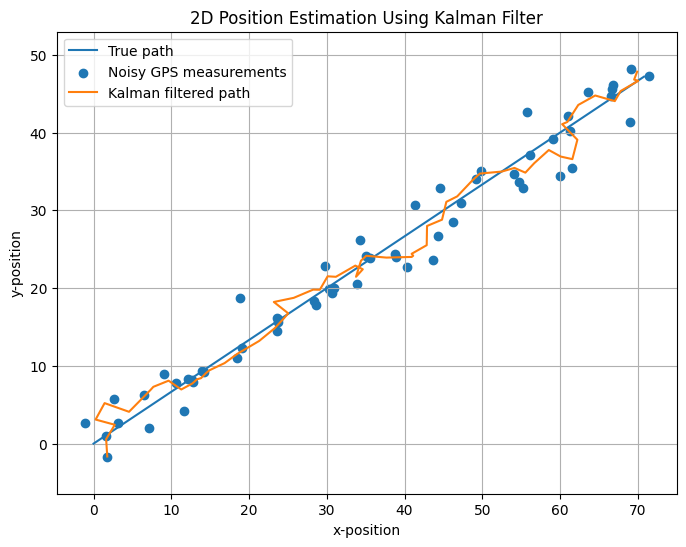

In [32]:
plt.figure(figsize=(8, 6))

plt.plot(true_states[:, 0], true_states[:, 1], label="True path")
plt.scatter(gps_measurements[:, 0], gps_measurements[:, 1], label="Noisy GPS measurements")
plt.plot(estimated_states[:, 0], estimated_states[:, 1], label="Kalman filtered path")

plt.xlabel("x-position")
plt.ylabel("y-position")
plt.title("2D Position Estimation Using Kalman Filter")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

### Step 6: Plot position components against time

The estimated \(x\)-position and \(y\)-position are plotted separately against time to observe how the Kalman filter smooths the noisy GPS measurements.

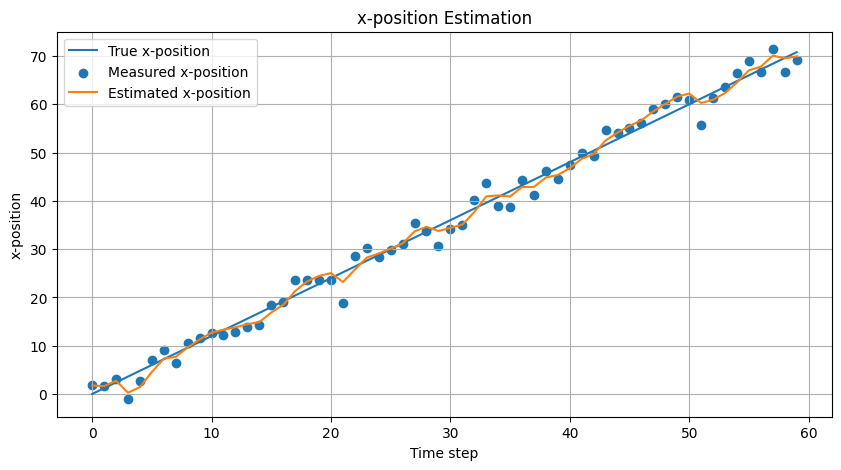

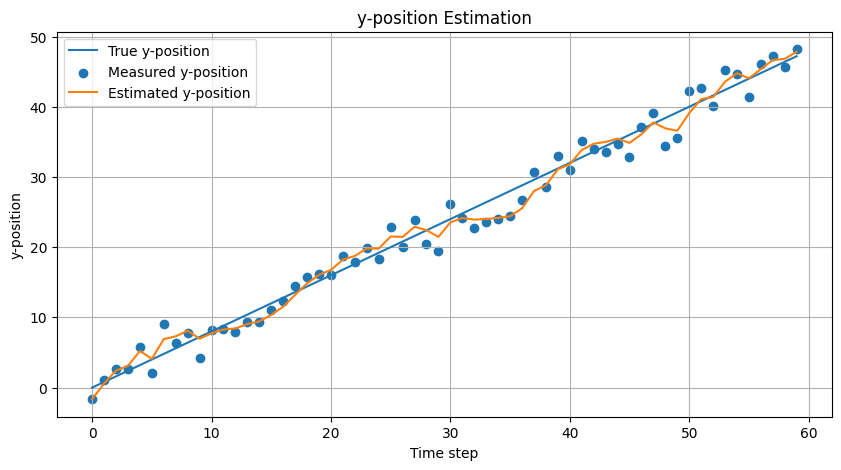

In [33]:
time = np.arange(N)

plt.figure(figsize=(10, 5))
plt.plot(time, true_states[:, 0], label="True x-position")
plt.scatter(time, gps_measurements[:, 0], label="Measured x-position")
plt.plot(time, estimated_states[:, 0], label="Estimated x-position")
plt.xlabel("Time step")
plt.ylabel("x-position")
plt.title("x-position Estimation")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(time, true_states[:, 1], label="True y-position")
plt.scatter(time, gps_measurements[:, 1], label="Measured y-position")
plt.plot(time, estimated_states[:, 1], label="Estimated y-position")
plt.xlabel("Time step")
plt.ylabel("y-position")
plt.title("y-position Estimation")
plt.legend()
plt.grid(True)
plt.show()

### Discussion

The noisy GPS measurements fluctuate around the true path because measurement noise has been added to the position data.

The Kalman filter gives a smoother estimate of the path by using both the constant-velocity motion model and the noisy GPS measurements. When the measurement is noisy, the filter does not fully trust the GPS reading. Instead, it balances the predicted position from the model with the observed position from the measurement.

As a result, the filtered path is closer to the true path and smoother than the raw GPS measurements.